<img src="https://github.com/pavlek358/DSB-Unit-02/blob/main/assets/ga-logo.png?raw=1" style="float: left; margin: 20px; height: 55px">

# Visualizing relationships

---

### About
Understand how to create charts within `pandas` using the `.plot()` method.

### Learning Objectives
- Apply appropriate chart types when exploring a data set.
- Explore patterns and relationships in data with bar charts and scatter plots.


### Notebook Guide
- Scenario
- Getting started with plotting in `pandas`
    - Bar charts
    - Scatter plots
- Now You Try!
- Conclusions and Takeaways

# Scenario

You're an analyst working for CoolBricks - a new toy company who wants to compete with LEGO by producing their own bricks and sets. To better understand what kind of sets to create and at what price points, you are tasked with analyzing LEGO's catalogue over time.

The data comes from Kaggle: [https://www.kaggle.com/datasets/alexracape/lego-sets-and-prices-over-time](https://www.kaggle.com/datasets/alexracape/lego-sets-and-prices-over-time)

We are going to use `pandas` to read this data and `matplotlib` to create plots.

## What is `matplotlib`?

- A visualization library (its name comes from MATLAB, plot, and library)
- The most universally used data visualization library for Python
- Tightly coupled with `pandas`, and `pandas` plots use `matplotlib` under the hood
- Can be used directly to fully control visualizations (in this notebook we will access it via the `pandas` `.plot()` method

# Getting started with plotting in `pandas`
---

array([[<Axes: title={'center': 'Year'}>,
        <Axes: title={'center': 'Num_Instructions'}>,
        <Axes: title={'center': 'Pieces'}>],
       [<Axes: title={'center': 'Minifigures'}>,
        <Axes: title={'center': 'Owned'}>,
        <Axes: title={'center': 'Rating'}>],
       [<Axes: title={'center': 'USD_MSRP'}>,
        <Axes: title={'center': 'Total_Quantity'}>,
        <Axes: title={'center': 'Current_Price'}>]], dtype=object)

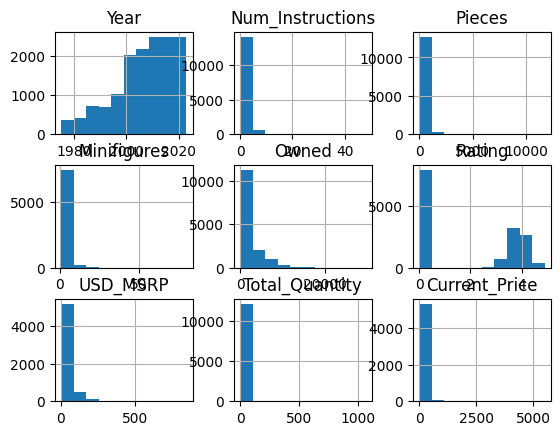

In [5]:
import pandas as pd

lego_df = pd.read_csv('https://raw.githubusercontent.com/pavlek358/DSB-Unit-02/refs/heads/main/data/lego.csv')
lego_df.hist()

Let's look at the data.

In [14]:
lego_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14936 entries, 0 to 14935
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Set_ID            14936 non-null  object 
 1   Name              14936 non-null  object 
 2   Year              14936 non-null  int64  
 3   Theme             14936 non-null  object 
 4   Theme_Group       14915 non-null  object 
 5   Subtheme          11495 non-null  object 
 6   Category          14936 non-null  object 
 7   Packaging         14936 non-null  object 
 8   Num_Instructions  14936 non-null  int64  
 9   Availability      14936 non-null  object 
 10  Pieces            13133 non-null  float64
 11  Minifigures       7686 non-null   float64
 12  Owned             14771 non-null  float64
 13  Rating            14936 non-null  float64
 14  USD_MSRP          5837 non-null   float64
 15  Total_Quantity    12276 non-null  float64
 16  Current_Price     5442 non-null   float6

One common way to create plots is on a `pandas` DataFrame directly.

When we run any `matplotlib`, the output will not only be a graph but also some text which is not formatted well.  To exclude the text, add a semicolon `;` to the end of the last line of code.

### Working with `matplotlib` in `pandas`

- For plots that require a *single* column of data (e.g. histograms), the plotting function (e.g. `.hist()`) is typically on the `Series`
- For plots whose underlying data requires *multiple* columns (e.g. scatter plots), the plotting function (e.g. `.plot()`) is typically on the `DataFrame`

Often, the best way to visualize data in Python is to:

- Transform the data into the appropriate shape
- Call a single function (usually `.plot()`)

***Note: for quick visualizations, we use `pandas` without even referencing `matplotlib` explicitly!***

## Bar charts

Let's say we want to visualize the **average price of a set for each theme group**

We can calculate this with a `.groupby()`

In [16]:
group_prices= lego_df.groupby("Theme_Group")["USD_MSRP"].median().sort_values(ascending = False)

This is fine, it answers our question, but it would be easier to compare groups visually.

Let's remove the `Vintage` category from our results since there aren't any price values for that category (which we know because there's a `NaN` where an average price should be).

In [30]:
group_prices= lego_df.groupby("Theme_Group")["USD_MSRP"].median().dropna().sort_values(ascending = False)


Now that we have the data in the right shape (in this case a `Series` with the index as the labels and the values as the result of the calculation) we only need a plotting function!

<Axes: xlabel='Theme_Group'>

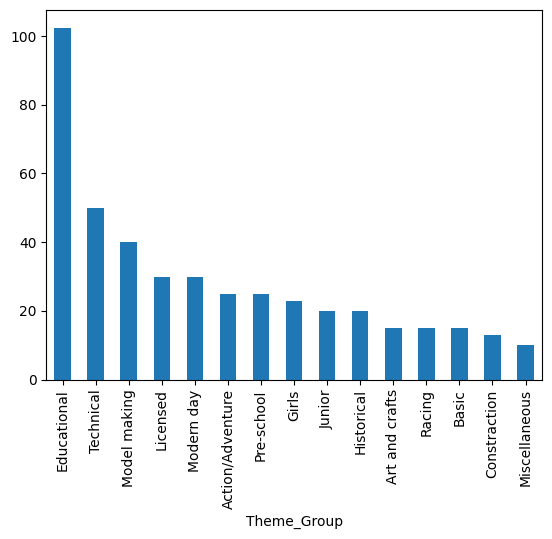

In [31]:
group_prices.plot(kind="bar")

This might look better as a horizontal bar chart.

Just change the plot "kind"!

<Axes: title={'center': 'Sets categorized'}, xlabel='Median retail price ($)', ylabel='Theme group'>

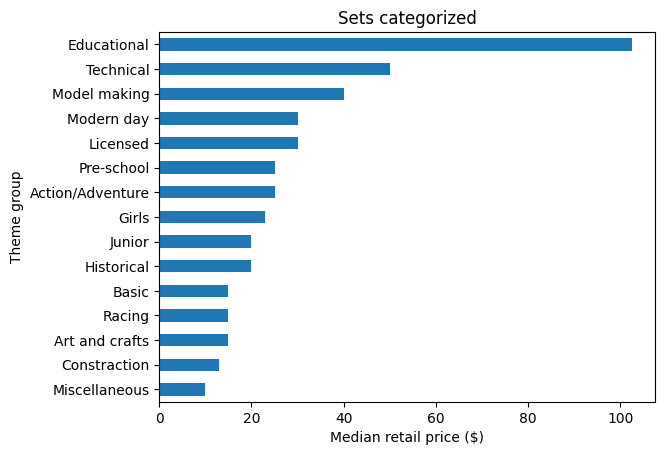

In [39]:
# group_prices.sort_values.plot(

#     kind="barh"
#    ,Title="Sets catogorized"
#    ,xlabel ="Median retaul price ($)"
#    ,ylabel= "Theme group"

#     )


group_prices.sort_values().plot(
    kind="barh",
    title="Sets categorized",
    xlabel="Median retail price ($)",
    ylabel="Theme group"
)

Note: for horizontal bar charts, data is presented from **the x-axis upwards** so if you want the bars to be in *descending* order, the data needs to be in *ascending* order

In [ ]:
lego

We can change some options too.

## Scatter plots

Let's find out if there is a link between a set's recommended retail price and its current retail price.

For scatter plots, we usually see *raw* data, not aggregations. This is why the plot function is called on the `DataFrame` directly.

<Axes: xlabel='USD_MSRP', ylabel='Current_Price'>

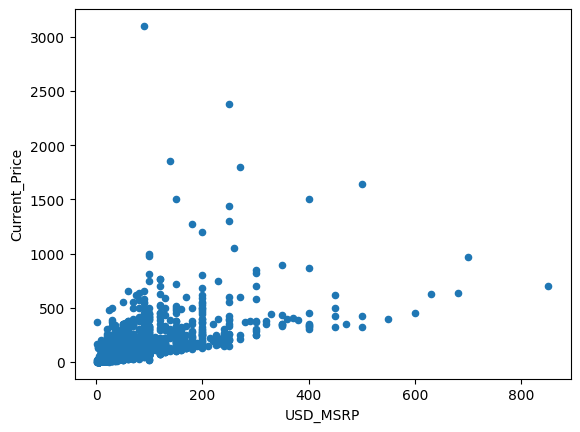

In [42]:
lego_df.plot(kind="scatter", x="USD_MSRP", y="Current_Price")

Looks like most sets can currently be bought at a similar price to the retail price with some outliers in both directions.

To make the "overplotting" effect less prominent (where lots of points make a dense area) we can alter the transparency of points.

Let's also get into the habit of changing some options.

<Axes: title={'center': 'Slack'}, xlabel='Who cares', ylabel='Current price in the market'>

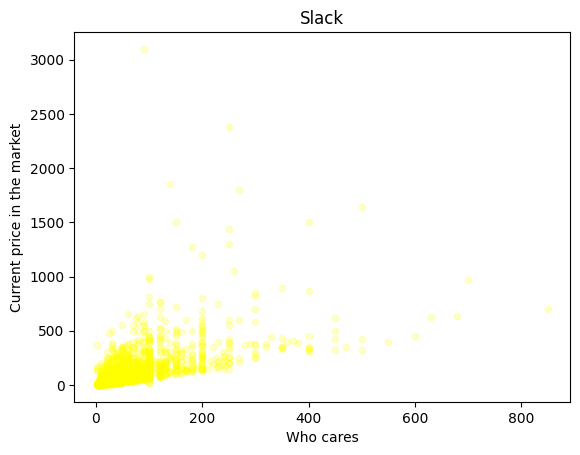

In [50]:
lego_df.plot(
    kind = "scatter"
    ,x="USD_MSRP"
    ,y="Current_Price"
    ,title="Slack"
    ,xlabel="Who cares"
    ,ylabel="Current price in the market"
    ,alpha=0.2
    ,color="yellow"

)

# Now You Try!
---

1. Calculate and visualize the *biggest* set (in terms of number of pieces) per theme group with a bar chart. Bonus: can you change the color of the bars?

In [53]:
lego_df.groupby("Theme_Group")[Prices].max.sort_values().plot(
    kind = "barh"
    ,x="USD_MSRP"
    ,y="Current_Price"
    ,title="Slack"
    ,xlabel="Who cares"
    ,ylabel="Current price in the market"
    ,alpha=0.2
    ,color="yellow"
)

NameError: name 'Prices' is not defined

2. Create a scatter plot to visualize the number of pieces versus the recommended retail price. Is there a relationship? Change any options in the plot you see fit.

KeyError: 'Recommended retail price'

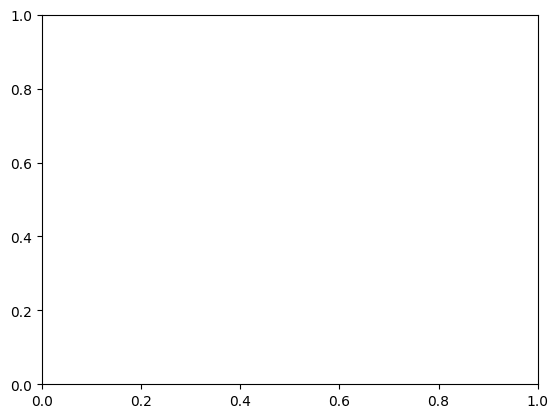

In [55]:
lego_df.plot(
    kind = "scatter"
    ,x="USD_MSRP"
    ,y="Recommended retail price"
    ,title="Slack"
    ,xlabel="Who cares"
    ,ylabel="Current price in the market"
    ,alpha=0.2
    ,color="yellow"
)

# Conclusions and Takeaways

- `pandas` lets us create visualizations directly from the data
- In `pandas`, plots are created with `matplotlib` under the hood
- For simple plots, we can use `pandas` methods without referencing `matplotlib` directly